In [2]:
import pathlib
from fastai.vision.all import PILImage, load_learner
import cv2
from matplotlib import pyplot as plt
import imutils
import numpy as np
import torch
from fastai.callback.wandb import WandbCallback
from fastai.callback.tracker import SaveModelCallback, EarlyStoppingCallback

In [3]:
path_image = 'Dartsify\\dataset\\cam3_090426_021017.jpg'

_temp = pathlib.PosixPath

pathlib.PosixPath = pathlib.WindowsPath

In [4]:
def get_x(row):
    return row['image_path']

def get_mask(row):
    return row['mask_path']

In [107]:
# PyTorch va vous afficher le vrai message d'erreur : "ModuleNotFoundError: No module named 'XXX'"
# modele_brut = torch.load(r"final\dartsify_ai_final.pkl", map_location='cpu', weights_only=False)

In [5]:
# learn = load_learner(r"final\\dartsify_ai_optuna_dicejaccard_20epochs.pkl")
learn = load_learner(r"final\\dartsify_ai_final.pkl")

c:\Users\craig\Documents\UNIVERSITE DE MONS\BAC3-Polytech\Q2\ProjetIG\algorithme-de-reconnaissance\.venv\Lib\site-packages\fastai\learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [6]:
learn.dls.after_item.fs

[AddMaskCodes(enc:0,dec:1), RandomCrop -- {'size': (512, 512), 'p': 1.0}
(enc:1,dec:0), ToTensor(enc:2,dec:0)]

In [7]:
transformations_sans_crop = [tfm for tfm in learn.dls.after_item.fs if 'Crop' not in type(tfm).__name__]

In [8]:
transformations_sans_crop

[AddMaskCodes(enc:0,dec:1), ToTensor(enc:2,dec:0)]

In [109]:
# NETTOYAGE CRITIQUE : On supprime les callbacks d'entraînement pour l'inférence
if WandbCallback in [type(cb) for cb in learn.cbs]:
    learn.remove_cb(WandbCallback)

if SaveModelCallback in [type(cb) for cb in learn.cbs]:
    learn.remove_cb(SaveModelCallback)

if EarlyStoppingCallback in [type(cb) for cb in learn.cbs]:
    learn.remove_cb(EarlyStoppingCallback)

In [110]:
image = PILImage.create(path_image)

In [111]:
after_item  = learn.dls.after_item     # resize, ToTensor, etc.
after_batch = learn.dls.after_batch    # Normalize, IntToFloat, etc.
 
x = after_item(image)              # apply item transforms
x = after_batch(x[None])               # add batch dim
 
learn.model.eval()
with torch.no_grad():
    out = learn.model(x.to(learn.dls.device))
    out = out.argmax(dim=1)

# Debug : vérifier la somme des valeurs du masque (normalement différent de 0 si il y a des points)
print("Somme des valeurs du masque :", out[0].numpy().sum())


Somme des valeurs du masque : 761


Aire détectée : 715.0
La fléchètte se trouve en : (327, 276)


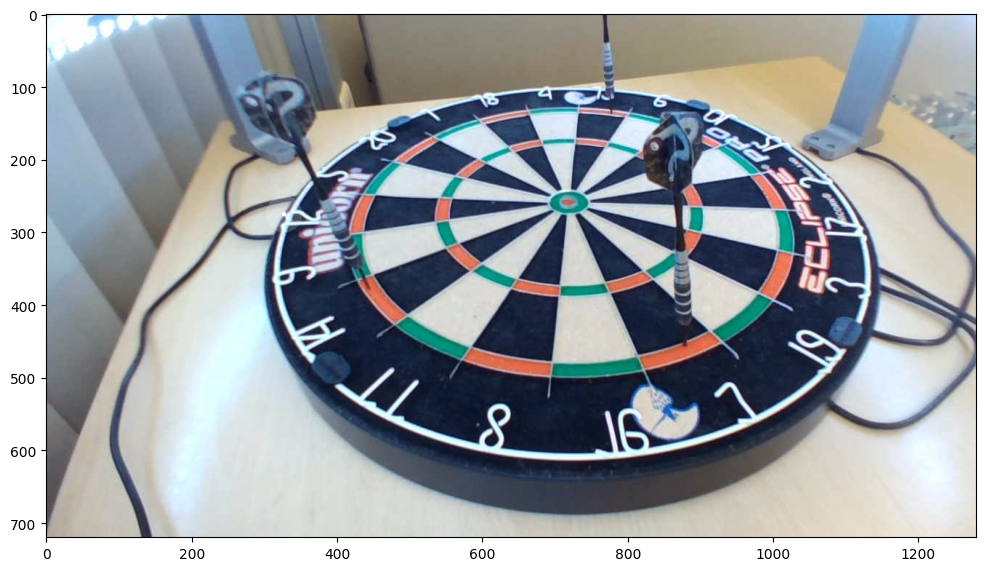

In [112]:
mask = out[0].numpy()

# garder seulement la classe "Point"
mask = (mask == 1).astype(np.uint8) * 255
"""
Etape post-traitement de l'image de sortie du modèle pour trouver les coordonnées de la fléchette
et les afficher sur l'image d'origine
"""
mask = cv2.convertScaleAbs(mask)

# trouver les contours de la fléchette
contours = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(contours)

image_np = np.array(image) # Convertir PILImage en tableau NumPy (format RGB)
image_bgr = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR) # Convertir RGB en BGR pour OpenCV
output = image_bgr.copy()
MIN_AREA = 100 # Seuil d'aire pour filtrer les petits contours (ajuster selon les résultats)
for c in contours:
    area = cv2.contourArea(c)
    print(f"Aire détectée : {area}") # Observe les petites valeurs vs les grandes

    # if area < MIN_AREA:
    #     continue

    M = cv2.moments(c)

    if M["m00"] == 0:
        continue

    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])
    print("La fléchètte se trouve en :", (cX, cY))

    overlay = output.copy()

    color = (255, 255, 255)
    cv2.circle(overlay, (cX, cY), 25, color, -1)

    alpha = 0.2
    cv2.addWeighted(overlay, alpha, output, 1 - alpha,0, output)

    cv2.circle(output, (cX, cY), 3, color, -1)

plt.figure(figsize = (12, 12))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
# plt.axis('off')
plt.show()